<a href="https://colab.research.google.com/github/dikshantdhanawade/deeplearning_clg/blob/main/Dl_Exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Embedding

In [2]:

vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)


max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
rnn_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_len),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
lstm_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_len),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [5]:
gru_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_len),
    GRU(32),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [6]:
epochs = 5
batch_size = 64

rnn_history = rnn_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

lstm_history = lstm_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

gru_history = gru_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.6039 - loss: 0.6422 - val_accuracy: 0.7804 - val_loss: 0.4647
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.8214 - loss: 0.4046 - val_accuracy: 0.8218 - val_loss: 0.4175
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9157 - loss: 0.2202 - val_accuracy: 0.8170 - val_loss: 0.4351
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.9704 - loss: 0.0929 - val_accuracy: 0.8254 - val_loss: 0.5228
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9907 - loss: 0.0383 - val_accuracy: 0.8218 - val_loss: 0.5777
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.7815 - loss: 0.4505 - val_accuracy: 0.8390 - val_loss: 0.3743
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.9051 - loss: 0.2452 - val_accuracy: 0.8692 - val_loss: 0.3279
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.9301 - loss: 0.1886 - val_accu

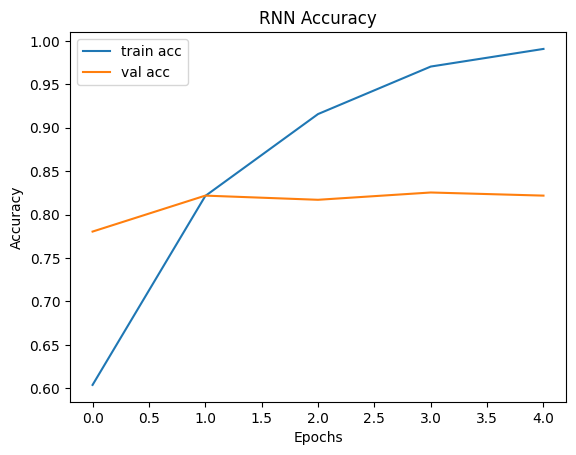

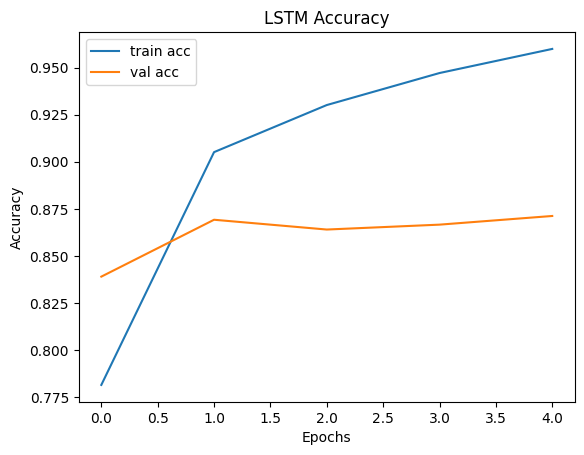

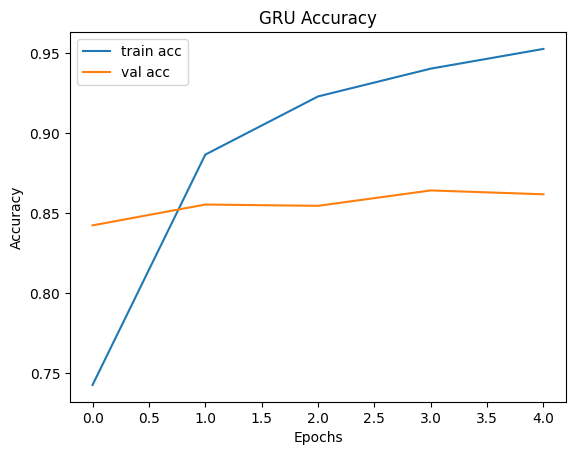

In [7]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='train acc')
    plt.plot(history.history['val_accuracy'], label='val acc')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(rnn_history, "RNN Accuracy")
plot_history(lstm_history, "LSTM Accuracy")
plot_history(gru_history, "GRU Accuracy")

In [9]:
print("RNN Test Accuracy:", rnn_model.evaluate(X_test, y_test)[1])
print("LSTM Test Accuracy:", lstm_model.evaluate(X_test, y_test)[1])
print("GRU Test Accuracy:", gru_model.evaluate(X_test, y_test)[1])

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8209 - loss: 0.5789
RNN Test Accuracy: 0.8209199905395508
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8600 - loss: 0.4223
LSTM Test Accuracy: 0.860040009021759
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8573 - loss: 0.4051
GRU Test Accuracy: 0.8573200106620789
